In [1]:
import os
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
import subprocess
import rasterio
import shapely
import rioxarray as rxr
import numpy as np
import geopandas as gpd
from osgeo import gdal
from geocube.vector import vectorize
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [2]:
load_dotenv()  # take environment variables from .env.

DATA_FOLDER = Path(os.getenv("DATA_FOLDER")) 
IMAGERY_FOLDER = DATA_FOLDER / "imagery" 
MASK_FOLDER = DATA_FOLDER / "geopackages"
uk_planet_folder = IMAGERY_FOLDER / "UK_planet_height"

In [3]:
def vectorise_raster(raster_path, vector_path, field_name, mask_and_scale=True, dissolve=True):

    raster = rxr.open_rasterio(raster_path, mask_and_scale=mask_and_scale).squeeze()
    raster.name = field_name
    vectorised_raster = vectorize(raster)

    res = vectorised_raster

    if dissolve:
        dissolved_raster = vectorised_raster.dissolve()

        res = dissolved_raster

    res.to_file(vector_path)

    return res

def getFeatures(gdf):
        """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
        import json
        return [json.loads(gdf.to_json())['features'][0]['geometry']]
    

In [148]:
from rasterio.features import shapes
from shapely.geometry import shape

def vectorise_raster(raster_data, transform, field_name, crs, dissolve=True):
    # Generate vector shapes from raster
    mask = raster_data != raster_data.min()  # Mask to exclude the background/nodata values
    vector_shapes = shapes(raster_data, mask=mask, transform=transform)

    # Convert the shapes and values to a GeoDataFrame
    records = []
    for geom, value in vector_shapes:
        records.append({
            'geometry': shape(geom),
            field_name: value
        })

    # Convert the shapes and values to a GeoDataFrame
    if records:  # Check if there are any records to avoid creating an empty GeoDataFrame
        gdf = gpd.GeoDataFrame(records)
        gdf.set_geometry('geometry', inplace=True)  # Ensure 'geometry' is the geometry column
        gdf = gdf.to_crs(crs)  # Assign CRS after confirming geometry presence

        # Optional dissolve step
        if dissolve:
            gdf = gdf.dissolve(by=field_name, as_index=False)

        return gdf
    else:
        return None  # Return None if no vector shapes were created

In [ ]:
# Load the primary layer
primary_layer_path = MASK_FOLDER / "GB_grids/5km_grid_region.shp"
primary_layer = gpd.read_file(primary_layer_path)
print(primary_layer.crs)
primary_layer

In [14]:
# Path to your VRT created earlier
vrt_path = IMAGERY_FOLDER / "UK_planet_height_dissolved" / "UK_planet_height_dissolved.vrt"

# Load the primary layer
primary_layer_path = MASK_FOLDER / "GB_grids/5km_grid_region.shp"
primary_layer = gpd.read_file(primary_layer_path)

# Extract extents (bounding boxes) of each feature
extents = primary_layer.geometry.bounds

uk_planet_folder = MASK_FOLDER / "UK_building_height_dissolved"
# Paths to your secondary layers

secondary_layer_dirs = [dir for dir in uk_planet_folder.glob('*/') if dir.is_dir]
secondary_layer_paths = list(secondary_layer_dirs[0].glob('*.gpkg'))
# 7302 .gpkg files

In [ ]:
for i, x in enumerate(secondary_layer_dirs):
    print(i, x.stem)

In [ ]:
secondary_layer_dirs.sort()
secondary_layer_dirs

In [ ]:
%%time
for big_tile in tqdm(secondary_layer_dirs[37:], desc='Big tile'):# Iterate over each secondary layer
    print(big_tile.stem)
    secondary_layer_paths = list(big_tile.glob('*.gpkg'))
    for sec_layer_path in tqdm(secondary_layer_paths, desc='Small tile'):

        try:
            # Load the secondary layer
            sec_layer = gpd.read_file(sec_layer_path).to_crs(primary_layer.crs)
            
            # Find overlaps with the primary layer using spatial join
            overlaps = gpd.sjoin(primary_layer, sec_layer, how='inner')
            primary_overlap_count = overlaps.groupby(['TILE_NAME'])['TILE_NAME'].count().sort_values(ascending=False)

            primary_tile_name = primary_overlap_count.index[0]

            primary_tile_name_gpd = primary_layer[primary_layer["TILE_NAME"] == primary_tile_name]
            # print("--", sec_layer_path.stem)
            # Open the VRT file with rasterio
            with rasterio.open(vrt_path) as src:
                raster_tile_folder = IMAGERY_FOLDER / "UK_planet_height_dissolved_tile" / sec_layer_path.stem[:2]
                raster_tile_folder.mkdir(parents=True, exist_ok=True)
                vector_tile_folder = MASK_FOLDER / "UK_planet_height_dissolved_tile" / sec_layer_path.stem[:2]
                vector_tile_folder.mkdir(parents=True, exist_ok=True)

                primary_tile_name_gpd = primary_tile_name_gpd.to_crs(src.crs)
                # Use the geometry to clip the VRT
                out_image, out_transform = mask(src, getFeatures(primary_tile_name_gpd['geometry']), crop=True)
                nodata_value = src.nodata
                if np.all(out_image == nodata_value):
                    print(f"{sec_layer_path.stem}_{primary_tile_name}")
                    continue
                
                # Define the metadata for the new TIFF
                out_meta = src.meta.copy()
                out_meta.update({"driver": "GTiff",
                                    "height": out_image.shape[1],
                                    "width": out_image.shape[2],
                                    "transform": out_transform})
                
                output_name = raster_tile_folder / f"UK_planet_height_dissolved_tile_{sec_layer_path.stem}_{primary_tile_name}.tif"
                # print(output_name)
                
                # Save the clipped area as a new TIFF file
                
                with rasterio.open(output_name, "w", **out_meta) as dest:
                    dest.write(out_image)

                vector_out = vector_tile_folder / f"UK_planet_height_dissolved_tile_{sec_layer_path.stem}_{primary_tile_name}.gpkg"

                # Vectorise
                vectorise_raster(output_name, vector_out, "height")
        except Exception as error:
            print(f"{sec_layer_path.stem}_{primary_tile_name}\n{error}")
# issues with sv, na, nf, sn, hz, nc, nd, nm, nj, nx
# DriverError: '/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/geopackages/UK_building_height_dissolved/nd/nd1550_dissolved.gpkg' not recognized as a supported file format.

Min value: 3
Max value: 255
Mean value: 247.37460273543508
Standard deviation: 42.73536706880161
False


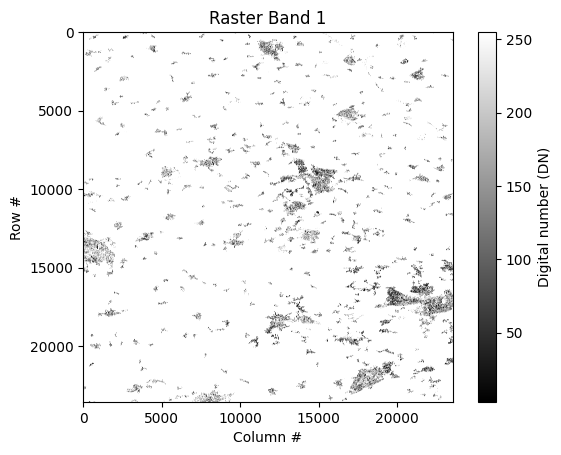

In [171]:
tif_path = "/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/imagery/UK_planet_height_dissolved_tile_fast/hp/UK_planet_height_dissolved_tile_HP40NE.tif"
tif_path = "/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/imagery/UK_planet_height_dissolved/ps_PSScene4Band_2019_-0002_00057_154_265_composite_lshm_processed_masked.tif"

with rasterio.open(tif_path) as src:
    # Read the first band (assuming your data of interest is in the first band)
    band1 = src.read(1)

    # Calculate statistics
    min_value = band1.min()
    max_value = band1.max()
    mean_value = band1.mean()
    std_dev = band1.std()

    print(f"Min value: {min_value}")
    print(f"Max value: {max_value}")
    print(f"Mean value: {mean_value}")
    print(f"Standard deviation: {std_dev}")

    print(min_value == max_value == mean_value)

    # Plot the band using matplotlib
    plt.imshow(band1, cmap='gray')  # Change 'gray' to another colormap if you prefer
    plt.colorbar(label='Digital number (DN)')
    plt.title('Raster Band 1')
    plt.xlabel('Column #')
    plt.ylabel('Row #')
    plt.show()

In [167]:
# Open the raster file
error_tiles =[]
empty_tiles = []
empty_vectors = []
with rasterio.open(vrt_path) as src:
    
    polygon_layer = primary_layer.copy().to_crs(src.crs)
    
    for index, row in tqdm(polygon_layer.iterrows()):
        # if index > 0:
        #     break
        tile_name = row.TILE_NAME
        # print(tile_name)
        # The geometry to mask the raster with
        tile_dir = output_folder / tile_name[:2].lower()
        tile_dir.mkdir(parents=True, exist_ok=True)
        geom = getFeatures(gpd.GeoDataFrame([row]))
        
        try:
            print('masking...')
            out_image, out_transform = mask(src, geom, crop=True)
            if out_image.size == 0 or out_image.mean() == src.nodata:
                empty_tiles.append(tile_name)
                continue
            print('vectorising...')
            vector_gdf = vectorise_raster(out_image[0], out_transform, 'height', src.crs, dissolve=True)
            
            # Save vectorized output
            if vector_gdf == None:
                empty_vectors.append(tile_name)
                continue
            print(tile_name)
            output_path = tile_dir / f"UK_planet_height_dissolved_tile_{tile_name}.geojson"
            vector_gdf.to_file(output_path, driver='GeoJSON')

            out_meta = src.meta.copy()

            # Update the metadata to reflect the number of layers,
            # and the new transformed affine and the new height and width
            out_meta.update({"driver": "GTiff",
                                "height": out_image.shape[1],
                                "width": out_image.shape[2],
                                "transform": out_transform})
            
            output_path = tile_dir / f"UK_planet_height_dissolved_tile_{tile_name}.tif"
            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image)
        
        except ValueError as e:
            print(e, index, tile_name)
            error_tiles.append(tile_name)

0it [00:00, ?it/s]

masking...


1it [00:03,  3.10s/it]

masking...


2it [00:06,  3.12s/it]

...

masking...


6it [00:18,  3.11s/it]

masking...


6it [16:48, 168.10s/it]


RasterioIOError: Read or write failed. '/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/imagery/UK_planet_height_dissolved/ps_PSScene4Band_2019_-0001_00067_170_278_100_0000_composite_lshm_processed_masked.tif' not recognized as a supported file format.

In [128]:
%%time
def clip_raster_by_features(raster_path, polygon_layer, output_folder):
    """
    Clips a raster based on features in a shapefile and saves the results as individual masked rasters.

    Parameters:
    - raster_path: Path to the raster file (e.g., a VRT file).
    - shapefile_path: Path to the shapefile containing the features to clip the raster with.
    - output_folder: Folder where the clipped raster files will be saved.
    """
    with rasterio.open(vrt_path) as src:
        polygon_layer = polygon_layer.copy().to_crs(src.crs)
        for index, row in tqdm(polygon_layer.iterrows()):

            tile_dir = output_folder / row.TILE_NAME[:2].lower()
        tile_dir.mkdir(parents=True, exist_ok=True)
        geom = getFeatures(gpd.GeoDataFrame([row]))
        
        try:
            out_image, out_transform = mask(src, geom, crop=True)
            if out_image.size == 0:
                continue

            vector_gdf = vectorise_raster(out_image[0], out_transform, 'height', src.crs, dissolve=True)
            
            # Save vectorized output
            if vector_gdf != None:
                output_path = tile_dir / f"UK_planet_height_dissolved_tile_{row.TILE_NAME}.geojson"
                vector_gdf.to_file(output_path, driver='GeoJSON')

            out_meta = src.meta.copy()

            # Update the metadata to reflect the number of layers,
            # and the new transformed affine and the new height and width
            out_meta.update({"driver": "GTiff",
                                "height": out_image.shape[1],
                                "width": out_image.shape[2],
                                "transform": out_transform})
            
            output_path = tile_dir / f"UK_planet_height_dissolved_tile_{row.TILE_NAME}.tif"
            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image)
        
        except ValueError as e:
            print(e, index, row.TILE_NAME)
            error_tiles.append(row.TILE_NAME)

output_folder = IMAGERY_FOLDER / "UK_planet_height_dissolved_tile"
clip_raster_by_features(primary_layer, vrt_path, output_folder)


TypeError: invalid path or file:       TILE_NAME                                           geometry
0        HP40NE  POLYGON ((445000.002 1210000.000, 449999.996 1...
1        HP40SE  POLYGON ((445000.002 1205000.002, 449999.996 1...
2        HP50NE  POLYGON ((454999.999 1210000.000, 460000.002 1...
3        HP50NW  POLYGON ((449999.996 1210000.000, 454999.999 1...
4        HP50SE  POLYGON ((454999.999 1205000.002, 460000.002 1...
...         ...                                                ...
10642    TV49NE  POLYGON ((545000.003 100000.005, 549999.997 10...
10643    TV49NW  POLYGON ((540000.000 100000.005, 545000.003 10...
10644    TV59NE  POLYGON ((555000.000 100000.005, 560000.003 10...
10645    TV59NW  POLYGON ((549999.997 100000.005, 555000.000 10...
10646    TV69NW  POLYGON ((560000.003 100000.005, 564999.998 10...

[10647 rows x 2 columns]

In [ ]:

for index, row in extents.iterrows():
    # Define the output filename for the TIFF
    output_tiff = f'tiled_output_{index}.tif'
    
    # Get the extent for the current feature
    minx, miny, maxx, maxy = row['minx'], row['miny'], row['maxx'], row['maxy']
    
    # GDAL Warp options to specify the cutline and output format
    options = gdal.WarpOptions(format='GTiff',
                               outputBounds=[minx, miny, maxx, maxy],
                               dstNodata=-9999)
    
    # Perform the clip and save as a new TIFF
    gdal.Warp(output_tiff, vrt_path, options=options)


In [6]:
# Example usage
raster_path = uk_planet_folder / "ps_PSScene4Band_2019_00000_00058_154_265_composite_lshm.tif"
vector_path = MASK_FOLDER / "BUA_2022_GB_3186007556224938771_dissolved.gpkg"
output_path = uk_planet_folder / "clipped_example.tif"
min_val, max_val = 3, 70 # Example value range

In [57]:
def getFeatures(gdf):
        """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
        import json
        return [json.loads(gdf.to_json())['features'][0]['geometry']]

def clip_and_mask_raster(raster_path, vector_path, output_path, min_val, max_val):
    """
    Clips a raster with a vector mask, masks out values outside the specified range, 
    and saves the output to a new file.

    Parameters:
        raster_path (str): Path to the raster file.
        vector_path (str): Path to the vector mask file.
        output_path (str): Where to save the clipped and masked raster.
        min_val (float): Minimum value to keep.
        max_val (float): Maximum value to keep.
    """
    # Load the vector mask
    vector_mask = gpd.read_file(vector_path)
    
    with rasterio.open(raster_path) as src:
        # Ensure the vector mask is in the same CRS as the raster
        vector_mask = vector_mask.to_crs(src.crs)
        
        # Clip the raster using the vector mask
        out_image, out_transform = mask(src, getFeatures(vector_mask), crop=True)
        
        # Retrieve nodata value from the raster metadata
        nodata = src.nodata
        
        # Mask out values outside the specified range
        out_image = np.where(
            (out_image < min_val) | (out_image > max_val),
            nodata,  # Use existing nodata value where condition is True
            out_image  # Keep original values where condition is False
        )
        
        # Prepare metadata for the output file
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
    
    # Write the clipped and masked raster to a new file
    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)


In [93]:
# Example usage
clip_and_mask_raster(
    raster_path,
    vector_path,
    output_path,
    min_val,
    max_val
)

In [14]:
raster = rxr.open_rasterio(output_path, mask_and_scale=True).squeeze()
raster.name = "height"
vectorised_raster = vectorize(raster)

In [15]:
vectorised_raster.to_file(MASK_FOLDER / "vectorised_example.geojson")

In [16]:
%%time
dissolved_raster = vectorised_raster.dissolve()

CPU times: user 2min 38s, sys: 1.53 s, total: 2min 39s
Wall time: 2min 40s


<Axes: >

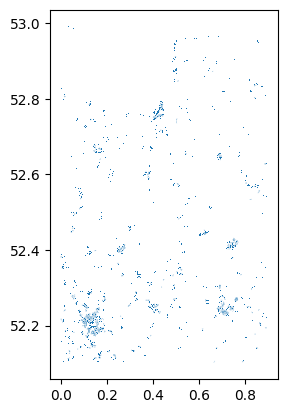

In [18]:
dissolved_raster.plot()

In [19]:
dissolved_raster.to_file(MASK_FOLDER / "vectorised_example_dissolved.gpkg")

In [18]:
building = gpd.read_file("/Users/ancazugo/Downloads/cam-gb-mm-bha-01/mm-bha/2017_10/gdb/tl/tl4560.gdb/a00000009.gdbtable")

In [20]:
from shapely.ops import nearest_points

In [36]:
# Initialize an R-tree spatial index for layer_many
sindex = building.sindex

# Define a function to find the closest point using spatial indexing to narrow down candidates
def find_closest_point_with_index(single_geom, many_gdf):

    # Assuming layer_single has only one feature, extract that single geometry
    single_feature_geom = single_geom.geometry.iloc[0]
    # Find approximate nearest neighbors in the R-tree index
    # This returns the indices of n nearest neighbors in the 'many' layer
    nearest_idx = list(sindex.nearest(single_geom.bounds, 1))
    
    # Retrieve the actual nearest geometry using these indices
    nearest_geom = many_gdf.iloc[nearest_idx].geometry
    
    # Calculate and return the actual nearest point
    return nearest_points(single_geom, nearest_geom.iloc[0])[1]

In [34]:
sindex

In [37]:
# Using tqdm for a progress bar (useful for large datasets)
# If you don't need a progress bar, you can remove tqdm()
building['closest_point'] = [find_closest_point_with_index(y, building) for _ in tqdm(range(len(building)))]

# Apply the function to each row in layer_many
# building['closest_point'] = building.apply(find_closest_point, target_geom=single_feature_geom, axis=1)


  0%|          | 0/19618 [00:00<?, ?it/s]


TypeError: Array should be one dimensional

In [26]:
from tqdm import tqdm

In [38]:
import geopandas as gpd
from shapely.ops import nearest_points
from concurrent.futures import ProcessPoolExecutor
import os

# Extract the single feature geometry
single_feature_geom = y.geometry.iloc[0]


In [39]:

def find_closest_point(feature, single_geom):
    """
    Find the closest point on single_geom to the given feature.
    This function is designed to be called in parallel.
    """
    return nearest_points(feature, single_geom)[1]

def process_feature(index_geom):
    """
    Wrapper function to process each feature. This extracts the feature geometry
    and passes it to the function calculating the closest point.
    """
    index, geom = index_geom
    return index, find_closest_point(geom, single_feature_geom)


In [65]:

# Tuple of (index, geometry) for each feature in layer_many
# features = list(building.geometry.iteritems())
features = [(i, building.iloc[i].geometry) for i in range(len(building[:100]))]
# Number of parallel processes to use
num_processes = os.cpu_count()

# Execute the find_closest_point function in parallel
with ProcessPoolExecutor(max_workers=num_processes) as executor:
    # Map the process_feature function across all features, in parallel
    results = list(executor.map(process_feature, features))

# Sort results by the original index to maintain order
results.sort(key=lambda x: x[0])

# Extract the closest points from the results
closest_points = [result[1] for result in results]

# Assign the closest points to the 'closest_point' column in the original GeoDataFrame
building['closest_point'] = closest_points

building


Process SpawnProcess-1:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/concurrent/futures/process.py", line 251, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_feature' on <module '__main__' (<class '

BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore